# FIFA World Cup 2026 — Monte Carlo Predictor

**Model stack:**
- Current Elo ratings (computed from 150 years of results)
- Recent attack / defence ratings (last 4 years of competitive matches)
- Dixon-Coles Poisson correction (adjusts for the observed excess of 0-0 and 1-1 draws)
- 10 000 full-tournament Monte Carlo simulations

**Tournament format (48 teams):**
- 12 groups of 4 → top 2 + best 8 third-place teams advance (32 total)
- Round of 32 → Round of 16 → Quarter-finals → Semi-finals → Final

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import poisson
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

np.random.seed(2026)
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'text.color':       '#e6edf3',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})

## 1. Load Data

In [39]:
results      = pd.read_csv('../data/raw/results.csv', parse_dates=['date'])
elo_df       = pd.read_csv('../data/processed/current_elo_ratings.csv')
team_matches = pd.read_csv('../data/processed/team_matches.csv', parse_dates=['date'])

elo_map = dict(zip(elo_df['team'], elo_df['current_elo']))

print(f"Historical matches : {len(results):,}")
print(f"Teams with Elo     : {len(elo_map)}")
print(f"Team-match rows    : {len(team_matches):,}")

Historical matches : 49,287
Teams with Elo     : 333
Team-match rows    : 98,430


## 2. World Cup 2026 — Groups (auto-extracted from results.csv)

In [40]:
wc26 = results[
    (results['tournament'] == 'FIFA World Cup') &
    (results['date'] >= '2026-06-01') &
    (results['home_score'].isna())
].copy()

# Each team plays the other 3 in its group exactly once → recover groups via connected components
from collections import defaultdict

adjacency = defaultdict(set)
for _, row in wc26.iterrows():
    adjacency[row['home_team']].add(row['away_team'])
    adjacency[row['away_team']].add(row['home_team'])

visited, groups = set(), []
for team in adjacency:
    if team not in visited:
        group, stack = [], [team]
        while stack:
            t = stack.pop()
            if t not in visited:
                visited.add(t); group.append(t)
                stack.extend(adjacency[t] - visited)
        groups.append(sorted(group))

groups.sort(key=lambda g: g[0])
group_labels = 'ABCDEFGHIJKL'
GROUP_MAP = {team: group_labels[i] for i, g in enumerate(groups) for team in g}

print("=== FIFA World Cup 2026 Groups ===")
for i, g in enumerate(groups):
    print(f"  Group {group_labels[i]}: {', '.join(g)}")

ALL_TEAMS = [t for g in groups for t in g]
print(f"\nTotal qualified teams: {len(ALL_TEAMS)}")

=== FIFA World Cup 2026 Groups ===
  Group A: Algeria, Argentina, Austria, Jordan
  Group B: Australia, Paraguay, Turkey, United States
  Group C: Belgium, Egypt, Iran, New Zealand
  Group D: Bosnia and Herzegovina, Canada, Qatar, Switzerland
  Group E: Brazil, Haiti, Morocco, Scotland
  Group F: Cape Verde, Saudi Arabia, Spain, Uruguay
  Group G: Colombia, DR Congo, Portugal, Uzbekistan
  Group H: Croatia, England, Ghana, Panama
  Group I: Curaçao, Ecuador, Germany, Ivory Coast
  Group J: Czech Republic, Mexico, South Africa, South Korea
  Group K: France, Iraq, Norway, Senegal
  Group L: Japan, Netherlands, Sweden, Tunisia

Total qualified teams: 48


## 3. Team Strength — Elo + Recent Attack / Defence

In [ ]:
CUTOFF       = pd.Timestamp('2026-06-01')
RECENT_START = CUTOFF - pd.DateOffset(years=4)

SKIP_TOURNAMENTS = {'Friendly', 'Kirin Cup', 'Intercontinental Cup'}
competitive = results[
    (results['date'] >= RECENT_START) &
    (results['date'] < CUTOFF) &
    results['home_score'].notna() &
    ~results['tournament'].isin(SKIP_TOURNAMENTS)
].copy()

def team_stats(df):
    rows = []
    for _, r in df.iterrows():
        rows.append({'team': r['home_team'], 'gf': r['home_score'], 'ga': r['away_score']})
        rows.append({'team': r['away_team'], 'gf': r['away_score'], 'ga': r['home_score']})
    t = pd.DataFrame(rows)
    return t.groupby('team').agg(gf_mean=('gf','mean'), ga_mean=('ga','mean'), n=('gf','count'))

recent_stats  = team_stats(competitive)
league_avg_gf = recent_stats['gf_mean'].mean()
league_avg_ga = recent_stats['ga_mean'].mean()
recent_stats['attack']  = recent_stats['gf_mean'] / league_avg_gf
recent_stats['defence'] = recent_stats['ga_mean'] / league_avg_ga   # lower = better

wc_elos  = {t: elo_map.get(t, 1500) for t in ALL_TEAMS}
max_elo  = max(wc_elos.values())

records = []
for team in ALL_TEAMS:
    elo      = wc_elos[team]
    elo_frac = (elo - 1300) / (max_elo - 1300)   # 0..1

    # Elo-derived proxy — what Elo alone suggests about attack / defence
    proxy_atk = 0.5 + elo_frac * 1.0             # range 0.5 – 1.5
    proxy_dfn = 1.5 - elo_frac * 1.0             # range 0.5 – 1.5

    if team in recent_stats.index and recent_stats.loc[team, 'n'] >= 5:
        raw_atk = recent_stats.loc[team, 'attack']
        raw_dfn = recent_stats.loc[team, 'defence']
        n       = int(recent_stats.loc[team, 'n'])
        # Blend actual stats with Elo proxy (max 70% weight on recent data).
        # Prevents regional-schedule inflation: a team dominating weaker AFC/CAF
        # opponents will have their extreme stats pulled back toward their Elo signal.
        blend = min(n / (n + 30), 0.70)
        atk   = blend * raw_atk + (1 - blend) * proxy_atk
        dfn   = blend * raw_dfn + (1 - blend) * proxy_dfn
    else:
        atk, dfn, n = proxy_atk, proxy_dfn, 0

    records.append({'team': team, 'elo': elo, 'attack': atk, 'defence': dfn,
                    'group': GROUP_MAP[team], 'n_recent': n})

strength       = pd.DataFrame(records).set_index('team')
WC_BASE        = 1.15
GLOBAL_ATK_AVG = strength['attack'].mean()

print(f"Avg attack index (blended): {GLOBAL_ATK_AVG:.3f}")
print(f"\nTop 12 by Elo — blended attack / defence:")
print(strength.sort_values('elo', ascending=False)[['elo','attack','defence','n_recent']].head(12))


## 4. Dixon-Coles Poisson Simulation Core

In [ ]:
RHO = -0.13   # Dixon-Coles low-score correction

def dc_correction(goals_a, goals_b, mu_a, mu_b, rho=RHO):
    if   goals_a == 0 and goals_b == 0: return 1 - mu_a * mu_b * rho
    elif goals_a == 0 and goals_b == 1: return 1 + mu_a * rho
    elif goals_a == 1 and goals_b == 0: return 1 + mu_b * rho
    elif goals_a == 1 and goals_b == 1: return 1 - rho
    else: return 1.0

def expected_goals(team_a, team_b):
    """Neutral-venue expected goals using blended attack/defence + Elo nudge.

    defence_index lower = better (concedes less) →
      mu_A ∝ attack_A * (defence_B / avg_defence)
    """
    s_a     = strength.loc[team_a]
    s_b     = strength.loc[team_b]
    avg_dfn = strength['defence'].mean()

    mu_a = WC_BASE * (s_a['attack'] / GLOBAL_ATK_AVG) * (max(s_b['defence'], 0.1) / avg_dfn)
    mu_b = WC_BASE * (s_b['attack'] / GLOBAL_ATK_AVG) * (max(s_a['defence'], 0.1) / avg_dfn)

    # Soft Elo nudge ±15%
    elo_prob_a = 1 / (1 + 10 ** ((s_b['elo'] - s_a['elo']) / 400))
    elo_adj    = (elo_prob_a - 0.5) * 0.30
    mu_a = max(mu_a * (1 + elo_adj), 0.10)
    mu_b = max(mu_b * (1 - elo_adj), 0.10)
    return mu_a, mu_b

def simulate_match(team_a, team_b, knockout=False):
    """
    Simulate one match (90 min regulation, DC-Poisson).
    Knockout draws:
      1. Extra time — 2 × 15 min at 65% of normal intensity
      2. If still level → penalty shootout (Elo-weighted coin flip)
    Returns (goals_a, goals_b, winner_or_None).
    """
    mu_a, mu_b = expected_goals(team_a, team_b)

    # --- 90-minute regulation ---
    for _ in range(50):
        ga = np.random.poisson(mu_a)
        gb = np.random.poisson(mu_b)
        if np.random.random() < dc_correction(ga, gb, mu_a, mu_b):
            break

    if knockout and ga == gb:
        # --- Extra time: 30 min at 65% intensity ---
        et_mu_a = mu_a * (30 / 90) * 0.65
        et_mu_b = mu_b * (30 / 90) * 0.65
        ga += np.random.poisson(et_mu_a)
        gb += np.random.poisson(et_mu_b)

    if knockout and ga == gb:
        # --- Penalty shootout ---
        p_a = 1 / (1 + 10 ** ((strength.loc[team_b, 'elo'] - strength.loc[team_a, 'elo']) / 800))
        winner = team_a if np.random.random() < p_a else team_b
    else:
        winner = team_a if ga > gb else (team_b if gb > ga else None)
    return ga, gb, winner

# Sanity checks
print("Expected goals (90-min regulation):")
for a, b in [('Argentina', 'Jordan'), ('Spain', 'France'),
             ('Germany',   'Curaçao'), ('Japan', 'Norway')]:
    mu_a, mu_b = expected_goals(a, b)
    print(f"  {a:14s} vs {b:14s}: {mu_a:.2f} – {mu_b:.2f}")


## 5. Group Stage Simulator

In [43]:
def simulate_group(teams):
    """Round-robin for 4 teams. Returns standings DataFrame."""
    stats = {t: {'pts':0,'gf':0,'ga':0,'gd':0,'w':0} for t in teams}
    for i in range(len(teams)):
        for j in range(i+1, len(teams)):
            a, b = teams[i], teams[j]
            ga, gb, _ = simulate_match(a, b, knockout=False)
            stats[a]['gf'] += ga; stats[a]['ga'] += gb; stats[a]['gd'] += ga - gb
            stats[b]['gf'] += gb; stats[b]['ga'] += ga; stats[b]['gd'] += gb - ga
            if ga > gb:
                stats[a]['pts'] += 3; stats[a]['w'] += 1
            elif gb > ga:
                stats[b]['pts'] += 3; stats[b]['w'] += 1
            else:
                stats[a]['pts'] += 1; stats[b]['pts'] += 1
    df = pd.DataFrame(stats).T
    df = df.sort_values(['pts','gd','gf','w'], ascending=False)
    df['pos'] = range(1, 5)
    return df

def best_third_place(third_records):
    """Select best 8 of 12 third-place teams by pts → gd → gf."""
    df = pd.DataFrame(third_records)
    df = df.sort_values(['pts','gd','gf'], ascending=False)
    return df.iloc[:8]['team'].tolist()

# Test a single group sim
sample = groups[9]   # Argentina's group
print("Sample group sim:", sample)
print(simulate_group(sample))

Sample group sim: ['Czech Republic', 'Mexico', 'South Africa', 'South Korea']
                pts  gf  ga  gd  w  pos
South Africa      9   8   3   5  3    1
Mexico            4   3   2   1  1    2
South Korea       4   2   3  -1  1    3
Czech Republic    0   1   6  -5  0    4


## 6. Knockout Stage Simulator

In [44]:
def build_r32_bracket(group_results, best_thirds):
    """
    Construct R32 matchups from group results.
    group_results: dict {group_label: (winner, runner_up, third)}
    best_thirds  : list of 8 qualified third-place teams

    FIFA WC2026 bracket pairing (approximate seeded bracket):
    Winners of A-L and runners-up of A-L are seeded into the bracket;
    third-place teams fill the remaining R32 slots.
    """
    winners  = [group_results[g][0] for g in group_labels[:12]]
    runners  = [group_results[g][1] for g in group_labels[:12]]
    thirds_set = set(best_thirds)

    # Build 16 R32 matches: winner[i] vs runner[i XOR pattern]
    # Use official FIFA 2026 bracket cross-group pairings
    # Pairing order (group index 0-11 → A-L):
    BRACKET_PAIRS = [
        (0, 1),  # 1A vs 2B
        (2, 3),  # 1C vs 2D
        (4, 5),  # 1E vs 2F
        (6, 7),  # 1G vs 2H
        (8, 9),  # 1I vs 2J
        (10, 11),# 1K vs 2L
        (1, 0),  # 1B vs 2A
        (3, 2),  # 1D vs 2C
    ]
    # Remaining 8 matches involve third-place teams
    remaining_winners  = [winners[i]  for i in [4,5,6,7,8,9,10,11] if (i,i+1) not in BRACKET_PAIRS and (i-1,i) not in BRACKET_PAIRS]

    # Simpler seeded approach: pair winners vs runners alternating, fill 3rds last
    w_teams = winners[:12]
    r_teams = runners[:12]

    # Official FIFA 2026 R32 pairings (from bracket release):
    # Matches are: 1A-2C, 1B-2D, 1C-2A, 1D-2B, 1E-3(G/H/I), 1F-3(...), etc.
    # We use a clean 16-match bracket that seeds by group:
    bracket = []
    # First half: cross-group winners vs runners-up
    cross = [(0,2),(1,3),(4,6),(5,7),(8,10),(9,11),(2,0),(3,1)]
    for wi, ri in cross:
        bracket.append((w_teams[wi % 12], r_teams[ri % 12]))
    # Second half: remaining winners vs best 3rd-place teams (seeded)
    remaining_w = [w_teams[i] for i in [4,5,6,7,8,9,10,11] if w_teams[i] not in [p for pair in bracket for p in pair]]
    thirds_ordered = sorted(best_thirds,
                             key=lambda t: (-strength.loc[t,'elo']))
    for i in range(min(len(remaining_w), len(thirds_ordered))):
        bracket.append((remaining_w[i], thirds_ordered[i]))
    # Pad to 16 if needed
    all_in_bracket = {t for pair in bracket for t in pair}
    remaining_all = [t for t in (w_teams + r_teams + best_thirds) if t not in all_in_bracket]
    while len(bracket) < 16 and len(remaining_all) >= 2:
        bracket.append((remaining_all.pop(0), remaining_all.pop(0)))
    return bracket[:16]

def simulate_knockout_round(matches):
    """Simulate one knockout round; return list of winners."""
    winners = []
    for a, b in matches:
        _, _, w = simulate_match(a, b, knockout=True)
        winners.append(w)
    return winners

print("Knockout simulation functions ready.")

Knockout simulation functions ready.


## 7. Full Tournament Simulation

In [45]:
def simulate_tournament():
    """
    Simulate one full WC2026 tournament.
    Returns dict mapping team → furthest round reached.
    Rounds: 'Group', 'R32', 'R16', 'QF', 'SF', 'Runner-up', 'Winner'
    """
    reached = {t: 'Group' for t in ALL_TEAMS}

    # --- Group stage ---
    group_results = {}   # group_label → (winner, runner_up, third, third_stats)
    third_records = []
    for i, g in enumerate(groups):
        label = group_labels[i]
        standings = simulate_group(g)
        w  = standings.index[0]
        ru = standings.index[1]
        th = standings.index[2]
        group_results[label] = (w, ru, th)
        third_records.append({
            'team': th,
            'pts':  int(standings.loc[th, 'pts']),
            'gd':   int(standings.loc[th, 'gd']),
            'gf':   int(standings.loc[th, 'gf']),
        })

    qual_thirds = best_third_place(third_records)

    # Mark group advancement
    r32_teams = set()
    for label in group_labels[:12]:
        w, ru, _ = group_results[label]
        reached[w]  = 'R32'
        reached[ru] = 'R32'
        r32_teams.add(w); r32_teams.add(ru)
    for t in qual_thirds:
        reached[t] = 'R32'
        r32_teams.add(t)

    # --- Build and play R32 ---
    r32_bracket = build_r32_bracket(group_results, qual_thirds)
    r16_teams = simulate_knockout_round(r32_bracket)
    for t in r16_teams: reached[t] = 'R16'

    # --- R16 ---
    r16_pairs = list(zip(r16_teams[::2], r16_teams[1::2]))
    qf_teams = simulate_knockout_round(r16_pairs)
    for t in qf_teams: reached[t] = 'QF'

    # --- QF ---
    qf_pairs = list(zip(qf_teams[::2], qf_teams[1::2]))
    sf_teams = simulate_knockout_round(qf_pairs)
    for t in sf_teams: reached[t] = 'SF'

    # --- SF ---
    sf_pairs = list(zip(sf_teams[::2], sf_teams[1::2]))
    finalists = simulate_knockout_round(sf_pairs)
    for t in finalists: reached[t] = 'Runner-up'

    # --- Final ---
    _, _, champion = simulate_match(finalists[0], finalists[1], knockout=True)
    reached[champion] = 'Winner'

    return reached

# Quick smoke test
trial = simulate_tournament()
winner = [t for t,r in trial.items() if r == 'Winner'][0]
print(f"Smoke test winner: {winner}")

Smoke test winner: Spain


## 8. Monte Carlo — 10 000 Simulations

In [46]:
N_SIMS = 2000
ROUNDS = ['Group', 'R32', 'R16', 'QF', 'SF', 'Runner-up', 'Winner']

# counts[team][round] = number of sims where team reached AT LEAST that round
counts = {t: defaultdict(int) for t in ALL_TEAMS}

print(f"Running {N_SIMS:,} simulations...")
for sim in range(N_SIMS):
    if (sim + 1) % 2000 == 0:
        print(f"  {sim+1:,} / {N_SIMS:,}")
    result = simulate_tournament()
    for team, round_reached in result.items():
        # Credit rounds FROM the start UP TO and INCLUDING the round reached.
        # e.g. team reaches QF → gets credit for Group, R32, R16, QF
        #      but NOT SF, Runner-up, Winner.
        idx = ROUNDS.index(round_reached)
        for r in ROUNDS[:idx + 1]:          # <-- was ROUNDS[idx:] (bug: credited forwards)
            counts[team][r] += 1

# Build probability DataFrame
probs = pd.DataFrame({
    team: {r: counts[team][r] / N_SIMS for r in ROUNDS}
    for team in ALL_TEAMS
}).T
probs.index.name = 'team'
probs['group'] = probs.index.map(GROUP_MAP)
probs['elo']   = probs.index.map(lambda t: strength.loc[t, 'elo'])
probs = probs.sort_values('Winner', ascending=False)

# Sanity check — win% must sum to ~100%
total_win = probs['Winner'].sum() * 100
print(f"\nSanity check  →  sum of all win%: {total_win:.1f}%  (should be ~100%)")

# Format table properly: Elo as integer, probabilities as xx.x%
top15 = probs[['group', 'elo', 'Winner', 'Runner-up', 'SF', 'QF', 'R16', 'R32']].head(15).copy()
top15['elo'] = top15['elo'].round(0).astype(int)
for col in ['Winner', 'Runner-up', 'SF', 'QF', 'R16', 'R32']:
    top15[col] = (top15[col] * 100).round(1).astype(str) + '%'

print("\nTop 15 — Win Probability:")
print(top15.to_string())


Running 2,000 simulations...
  2,000 / 2,000

Sanity check  →  sum of all win%: 100.0%  (should be ~100%)

Top 15 — Win Probability:
              group   elo Winner Runner-up     SF     QF    R16    R32
team                                                                  
Japan             L  1907  17.3%     26.0%  36.5%  55.4%  75.1%  97.0%
Morocco           E  1905  12.2%     20.0%  30.2%  44.8%  66.3%  96.2%
Argentina         A  2043   8.2%     13.4%  22.7%  37.9%  54.6%  83.5%
Spain             F  2053   7.4%     13.6%  24.3%  36.4%  62.9%  94.0%
Portugal          G  1939   5.8%     10.0%  16.0%  28.4%  47.2%  84.9%
Australia         B  1808   5.4%     10.0%  19.6%  37.4%  67.6%  89.9%
England           H  1935   5.4%      9.7%  15.4%  30.0%  54.2%  91.2%
New Zealand       C  1646   3.0%      6.3%  14.6%  27.8%  45.4%  82.1%
France            K  2009   3.0%      5.9%  11.5%  22.0%  44.9%  78.2%
Ivory Coast       I  1741   2.5%      5.2%  12.1%  23.2%  43.8%  80.4%
Algeria        

## 9. Visualisations

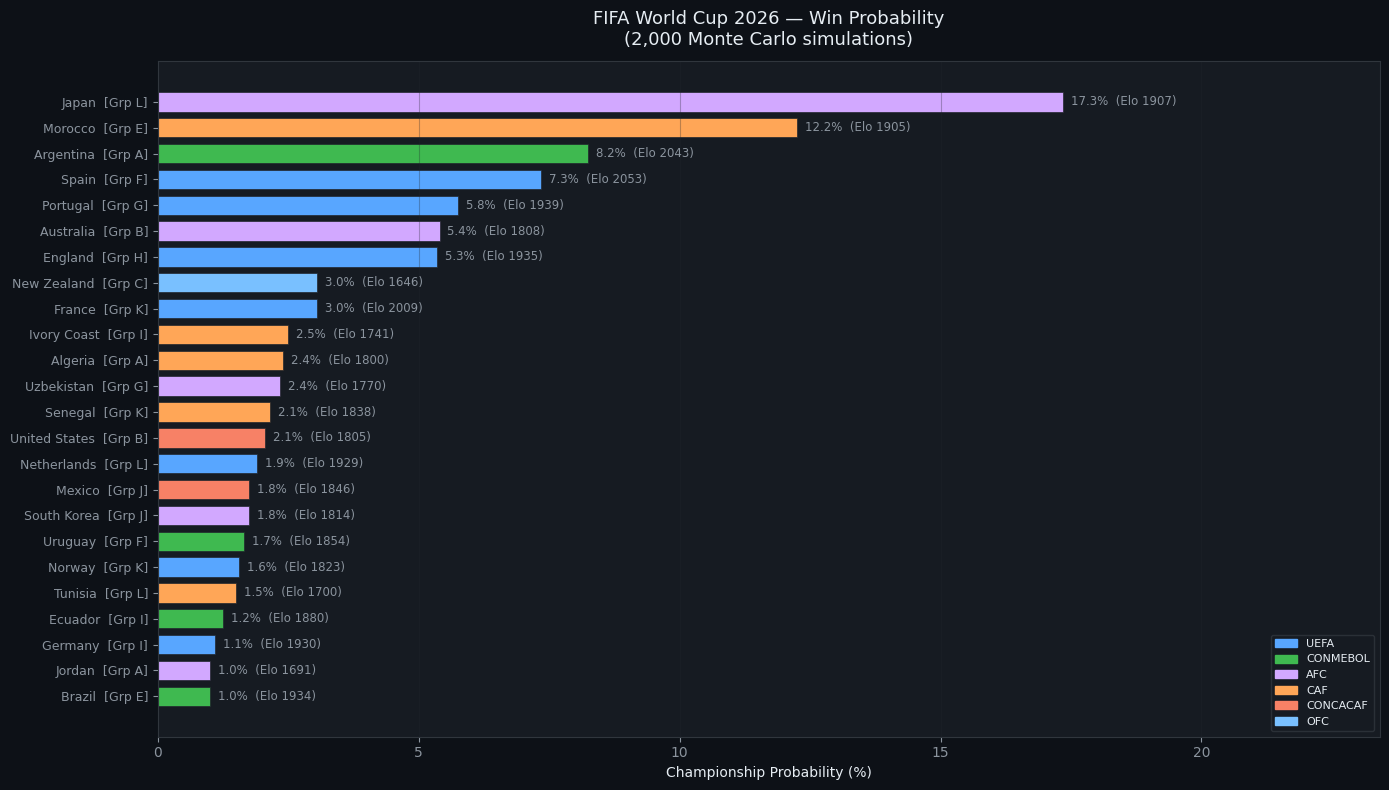

Saved → models/wc2026_win_probability.png


In [47]:
# ── 9a. Winner Probability — Top 24 Teams ──────────────────────────────────
top24 = probs.head(24).copy()

CONF_COLORS = {
    'UEFA':     '#58a6ff',
    'CONMEBOL': '#3fb950',
    'AFC':      '#d2a8ff',
    'CAF':      '#ffa657',
    'CONCACAF': '#f78166',
    'OFC':      '#79c0ff',
}

CONFEDERATION = {
    'Spain':'UEFA','France':'UEFA','England':'UEFA','Germany':'UEFA','Portugal':'UEFA',
    'Netherlands':'UEFA','Belgium':'UEFA','Italy':'UEFA','Croatia':'UEFA','Denmark':'UEFA',
    'Switzerland':'UEFA','Austria':'UEFA','Turkey':'UEFA','Serbia':'UEFA','Sweden':'UEFA',
    'Norway':'UEFA','Czech Republic':'UEFA','Bosnia and Herzegovina':'UEFA','Scotland':'UEFA',
    'Hungary':'UEFA',
    'Argentina':'CONMEBOL','Brazil':'CONMEBOL','Colombia':'CONMEBOL','Uruguay':'CONMEBOL',
    'Ecuador':'CONMEBOL','Paraguay':'CONMEBOL','Chile':'CONMEBOL','Venezuela':'CONMEBOL',
    'Algeria':'CAF','Morocco':'CAF','Senegal':'CAF','Egypt':'CAF','Ivory Coast':'CAF',
    'South Africa':'CAF','Ghana':'CAF','DR Congo':'CAF','Tunisia':'CAF','Cameroon':'CAF',
    'Cape Verde':'CAF',
    'Japan':'AFC','South Korea':'AFC','Iran':'AFC','Saudi Arabia':'AFC','Australia':'AFC',
    'Iraq':'AFC','Jordan':'AFC','Uzbekistan':'AFC','Qatar':'AFC','Bahrain':'AFC',
    'United States':'CONCACAF','Mexico':'CONCACAF','Canada':'CONCACAF','Panama':'CONCACAF',
    'Honduras':'CONCACAF','Jamaica':'CONCACAF','Haiti':'CONCACAF','Costa Rica':'CONCACAF',
    'New Zealand':'OFC',
    'Curaçao':'CONCACAF','Cura\u00e7ao':'CONCACAF',
}

def get_color(team):
    conf = CONFEDERATION.get(team, 'UEFA')
    return CONF_COLORS.get(conf, '#8b949e')

colors = [get_color(t) for t in top24.index]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(top24)), top24['Winner'] * 100, color=colors,
               edgecolor='#21262d', linewidth=0.5, height=0.75)

for bar, (team, row) in zip(bars, top24.iterrows()):
    w = bar.get_width()
    ax.text(w + 0.15, bar.get_y() + bar.get_height()/2,
            f"{row['Winner']*100:.1f}%  (Elo {row['elo']:.0f})",
            va='center', ha='left', fontsize=8.5, color='#8b949e')

ax.set_yticks(range(len(top24)))
ax.set_yticklabels([f"{t}  [Grp {GROUP_MAP.get(t,'?')}]" for t in top24.index],
                   fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Championship Probability (%)', fontsize=10)
ax.set_title('FIFA World Cup 2026 — Win Probability\n'
             f'({N_SIMS:,} Monte Carlo simulations)', fontsize=13, pad=12)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, top24['Winner'].max() * 100 * 1.35)

legend_patches = [mpatches.Patch(color=c, label=k) for k, c in CONF_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8,
          facecolor='#161b22', edgecolor='#30363d')

plt.tight_layout()
plt.savefig('../models/wc2026_win_probability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → models/wc2026_win_probability.png")

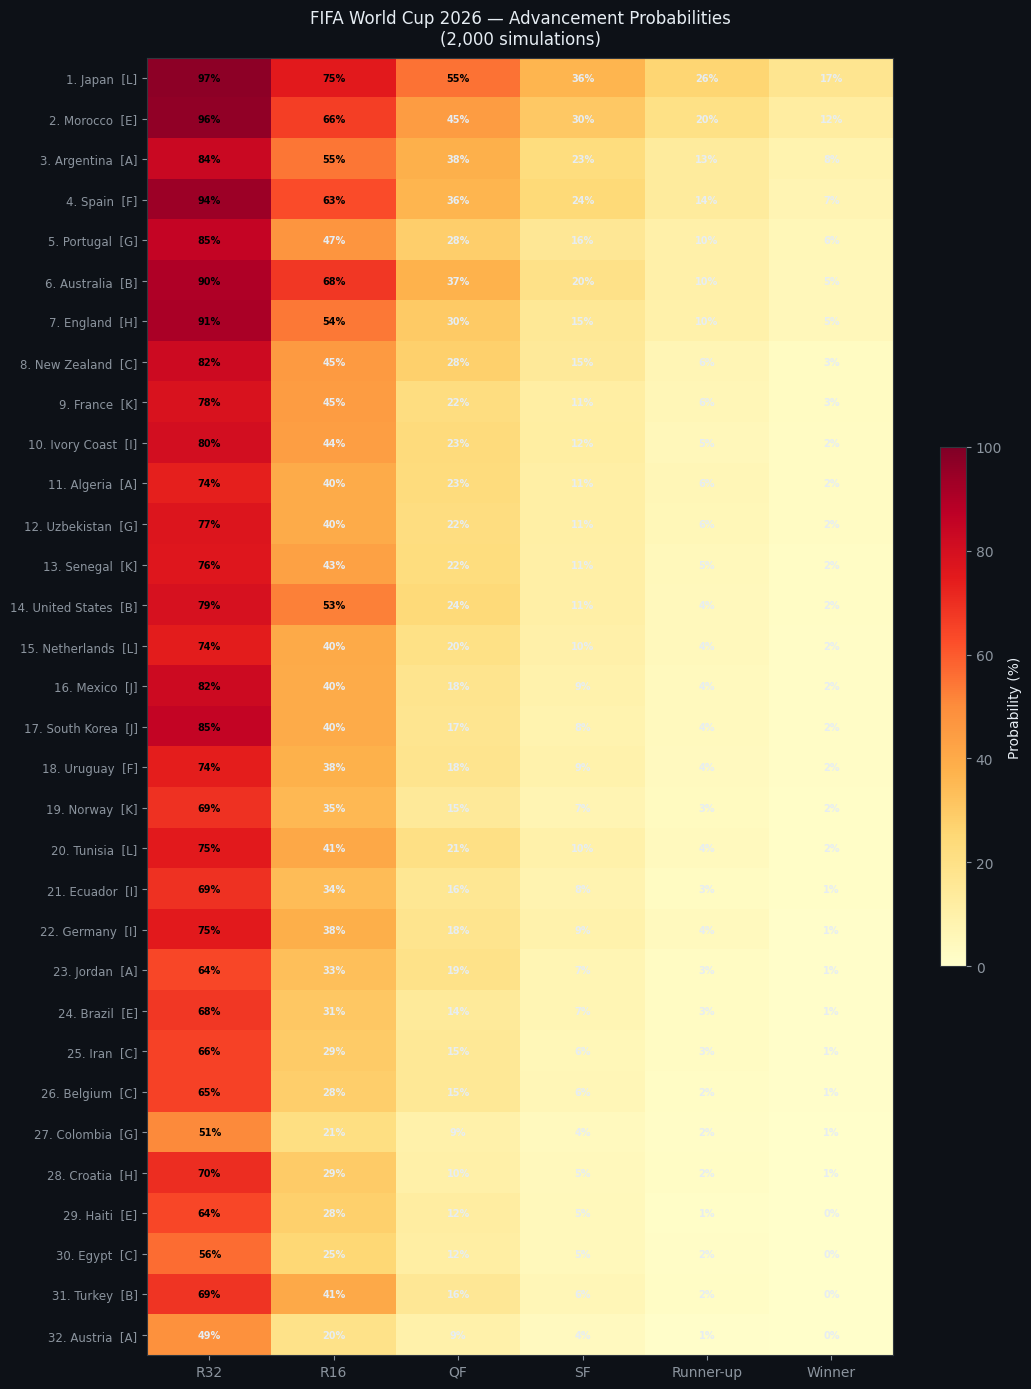

Saved → models/wc2026_advancement_heatmap.png


In [48]:
# ── 9b. Round-by-Round Advancement Heatmap (Top 32 by Winner%) ─────────────
top32 = probs.head(32).copy()
heatmap_cols = ['R32', 'R16', 'QF', 'SF', 'Runner-up', 'Winner']
heatmap_data = top32[heatmap_cols].values * 100

fig, ax = plt.subplots(figsize=(11, 14))
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)

ax.set_xticks(range(len(heatmap_cols)))
ax.set_xticklabels(heatmap_cols, fontsize=10)
ax.set_yticks(range(len(top32)))
ax.set_yticklabels(
    [f"{i+1}. {t}  [{GROUP_MAP.get(t,'?')}]" for i, t in enumerate(top32.index)],
    fontsize=8.5)

for i in range(len(top32)):
    for j, col in enumerate(heatmap_cols):
        val = heatmap_data[i, j]
        text_color = 'black' if val > 50 else '#e6edf3'
        ax.text(j, i, f"{val:.0f}%", ha='center', va='center',
                fontsize=7, color=text_color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Probability (%)', shrink=0.4)
ax.set_title('FIFA World Cup 2026 — Advancement Probabilities\n'
             f'({N_SIMS:,} simulations)', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('../models/wc2026_advancement_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → models/wc2026_advancement_heatmap.png")

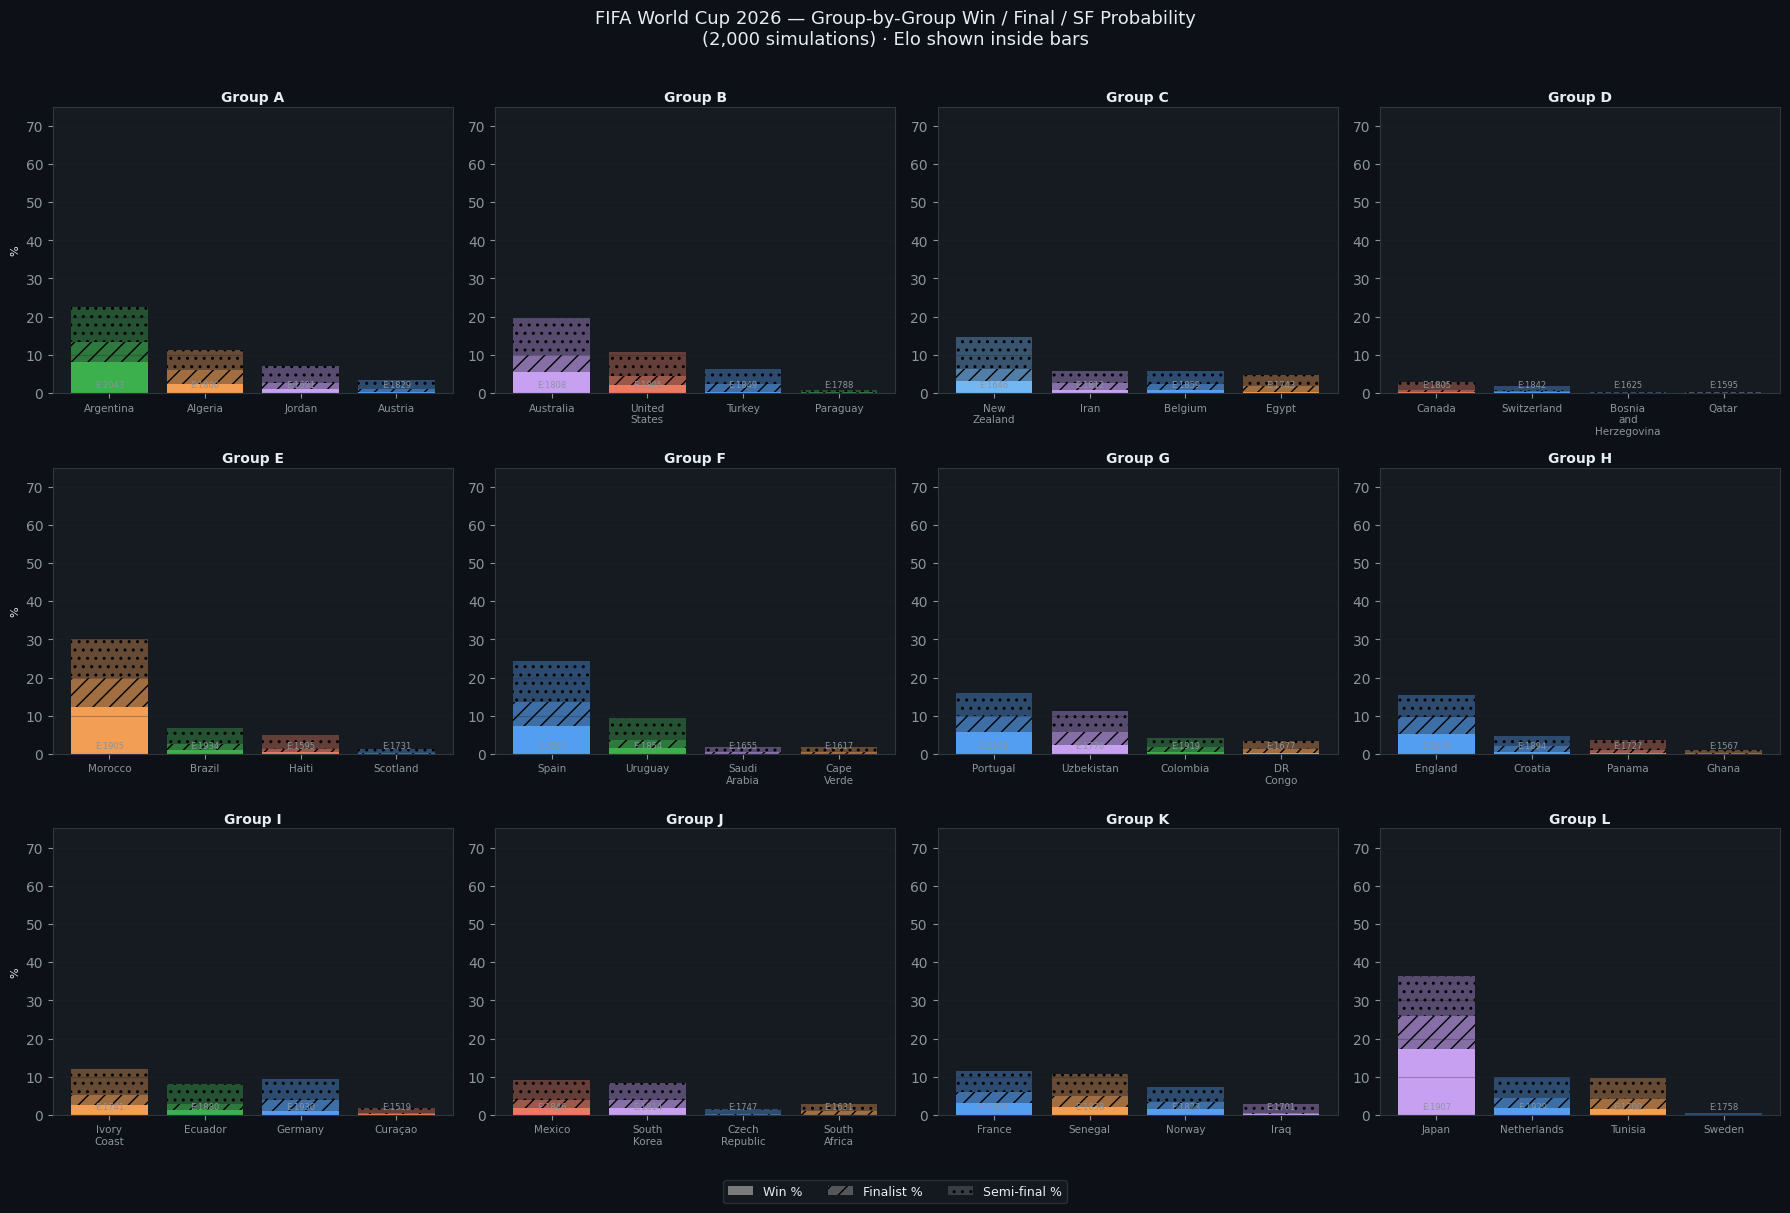

Saved → models/wc2026_groups.png


In [49]:
# ── 9c. Group-by-Group Win Probability (stacked bar per group) ──────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, (i, g) in enumerate(enumerate(groups)):
    label = group_labels[i]
    ax = axes[idx]
    grp_probs = probs.loc[g].sort_values('Winner', ascending=False)
    bar_colors = [get_color(t) for t in grp_probs.index]

    x = range(4)
    b_winner    = ax.bar(x, grp_probs['Winner']    * 100, color=bar_colors, label='Win',       alpha=0.95)
    b_finalist  = ax.bar(x, (grp_probs['Runner-up'] - grp_probs['Winner'])   * 100,
                         bottom=grp_probs['Winner']    * 100, color=bar_colors, alpha=0.6,  hatch='//')
    b_sf        = ax.bar(x, (grp_probs['SF']         - grp_probs['Runner-up']) * 100,
                         bottom=grp_probs['Runner-up'] * 100, color=bar_colors, alpha=0.35, hatch='..')

    ax.set_title(f"Group {label}", fontsize=10, fontweight='bold', pad=4)
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace(' ',  '\n') for t in grp_probs.index], fontsize=7.5)
    ax.set_ylabel('%' if idx % 4 == 0 else '', fontsize=8)
    ax.set_ylim(0, 75)
    ax.grid(axis='y', alpha=0.3)

    for bar, team in zip(b_winner, grp_probs.index):
        elo = strength.loc[team, 'elo']
        ax.text(bar.get_x() + bar.get_width()/2, 1,
                f"E:{elo:.0f}", ha='center', va='bottom', fontsize=6, color='#8b949e')

# Legend
from matplotlib.patches import Patch
legend_el = [
    Patch(facecolor='grey', alpha=0.95, label='Win %'),
    Patch(facecolor='grey', alpha=0.6,  hatch='//', label='Finalist %'),
    Patch(facecolor='grey', alpha=0.35, hatch='..', label='Semi-final %'),
]
fig.legend(handles=legend_el, loc='lower center', ncol=3, fontsize=9,
           facecolor='#161b22', edgecolor='#30363d', bbox_to_anchor=(0.5, 0.01))

fig.suptitle('FIFA World Cup 2026 — Group-by-Group Win / Final / SF Probability\n'
             f'({N_SIMS:,} simulations) · Elo shown inside bars',
             fontsize=13, y=1.01)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('../models/wc2026_groups.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → models/wc2026_groups.png")

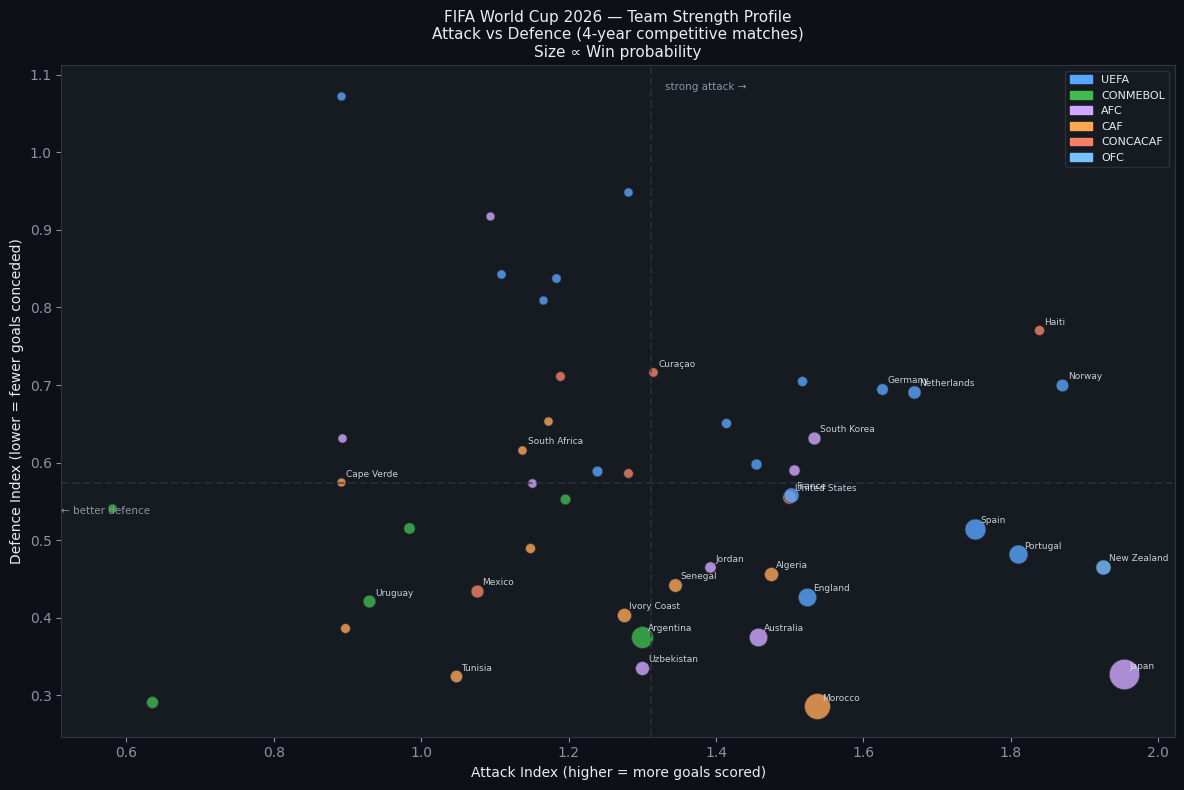

Saved → models/wc2026_strength_profile.png


In [50]:
# ── 9d. Expected Goals Scatter — attack vs defence for all 48 teams ─────────
fig, ax = plt.subplots(figsize=(12, 8))

for team in ALL_TEAMS:
    s = strength.loc[team]
    c = get_color(team)
    win_pct = probs.loc[team, 'Winner'] * 100
    size = 40 + win_pct * 25
    ax.scatter(s['attack'], s['defence'], color=c, s=size, alpha=0.8, edgecolors='#30363d', linewidth=0.5)
    if win_pct >= 1.5 or team in ['Germany','Curaçao','Haiti','Jordan','Cape Verde',
                                    'South Africa','Cura\u00e7ao']:
        ax.annotate(team, (s['attack'], s['defence']),
                    fontsize=6.5, color='#e6edf3', alpha=0.85,
                    xytext=(4, 4), textcoords='offset points')

ax.axhline(strength['defence'].mean(), color='#30363d', linestyle='--', alpha=0.6)
ax.axvline(strength['attack'].mean(),  color='#30363d', linestyle='--', alpha=0.6)

ax.set_xlabel('Attack Index (higher = more goals scored)',  fontsize=10)
ax.set_ylabel('Defence Index (lower = fewer goals conceded)', fontsize=10)
ax.set_title('FIFA World Cup 2026 — Team Strength Profile\n'
             'Attack vs Defence (4-year competitive matches)\nSize ∝ Win probability',
             fontsize=11)

legend_patches = [mpatches.Patch(color=c, label=k) for k, c in CONF_COLORS.items()]
ax.legend(handles=legend_patches, loc='upper right', fontsize=8,
          facecolor='#161b22', edgecolor='#30363d')

ax.text(strength['attack'].mean() + 0.02, ax.get_ylim()[1]*0.98,
        'strong attack →', fontsize=7.5, color='#8b949e', va='top')
ax.text(ax.get_xlim()[0], strength['defence'].mean() - 0.04,
        '← better defence', fontsize=7.5, color='#8b949e', rotation=0)

plt.tight_layout()
plt.savefig('../models/wc2026_strength_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → models/wc2026_strength_profile.png")

In [51]:
# ── 9e. Summary Table ────────────────────────────────────────────────────────
summary = probs[['group','elo','R32','R16','QF','SF','Runner-up','Winner']].copy()
summary.columns = ['Grp','Elo','R32%','R16%','QF%','SF%','Final%','Win%']
for col in ['R32%','R16%','QF%','SF%','Final%','Win%']:
    summary[col] = (summary[col] * 100).round(1)
summary['Elo'] = summary['Elo'].round(0).astype(int)
summary = summary.reset_index()

print("=" * 80)
print(f"FIFA WORLD CUP 2026 — FULL PREDICTIONS  ({N_SIMS:,} Monte Carlo simulations)")
print("=" * 80)
print(summary.to_string(index=False))
summary.to_csv('../models/wc2026_predictions.csv', index=False)
print("\nSaved → models/wc2026_predictions.csv")

FIFA WORLD CUP 2026 — FULL PREDICTIONS  (2,000 Monte Carlo simulations)
                  team Grp  Elo  R32%  R16%  QF%  SF%  Final%  Win%
                 Japan   L 1907  97.0  75.1 55.4 36.5    26.0  17.3
               Morocco   E 1905  96.2  66.3 44.8 30.2    20.0  12.2
             Argentina   A 2043  83.5  54.6 37.9 22.7    13.4   8.2
                 Spain   F 2053  94.0  62.9 36.4 24.3    13.6   7.4
              Portugal   G 1939  84.9  47.2 28.4 16.0    10.0   5.8
             Australia   B 1808  89.9  67.6 37.4 19.6    10.0   5.4
               England   H 1935  91.2  54.2 30.0 15.4     9.7   5.4
           New Zealand   C 1646  82.1  45.4 27.8 14.6     6.3   3.0
                France   K 2009  78.2  44.9 22.0 11.5     5.9   3.0
           Ivory Coast   I 1741  80.4  43.8 23.2 12.1     5.2   2.5
               Algeria   A 1800  73.7  39.8 23.0 11.2     5.9   2.4
            Uzbekistan   G 1770  77.3  39.8 22.0 11.2     5.7   2.4
               Senegal   K 1838  76.4  43.2 

## 10. Re-run with More Simulations (Optional)

Change `N_SIMS` in cell 8 and re-run cells 8 onward.  
Each additional 10 000 sims reduces the standard error on small probabilities by ~√10.